# Prediksi Risiko Dropout Mahasiswa
Notebook untuk dataset **Students' Dropout and Academic Success**.

## 1. Import Library

In [126]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


## 2. Cek Path Dataset di Kaggle

In [127]:

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/muhammadzackyrachim/dataset/data.csv


## 3. Load Dataset


In [128]:
df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/dataset/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 4. Data Understanding

In [129]:

print("Shape data:", df.shape)
print(df.columns.tolist())
df.info()
print(df.isnull().sum())
print("Duplikat:", df.duplicated().sum())


Shape data: (4424, 37)
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP'

## 5. Ubah Target Menjadi Biner

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
dropout_risk
0    3003
1    1421
Name: count, dtype: int64


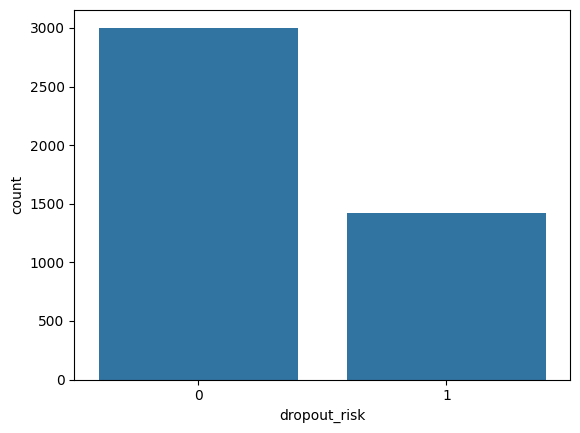

In [130]:

print(df['Target'].value_counts())
df['dropout_risk'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
print(df['dropout_risk'].value_counts())
sns.countplot(x='dropout_risk', data=df)
plt.show()


## 6. EDA

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


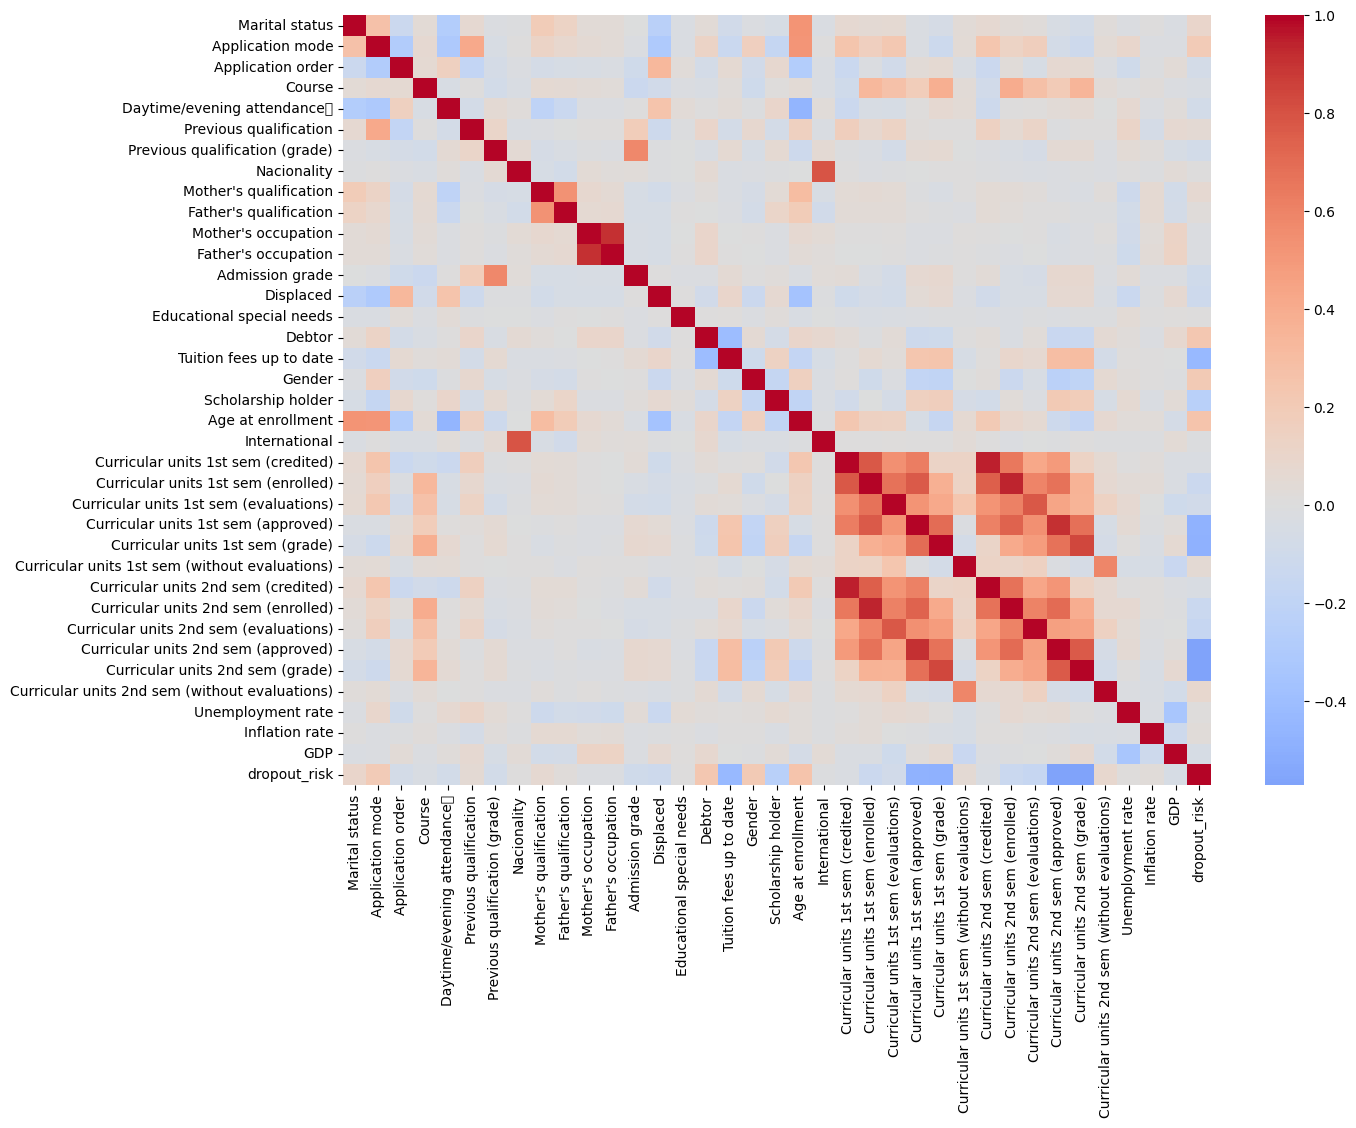

dropout_risk                                      1.000000
Age at enrollment                                 0.254215
Debtor                                            0.229407
Gender                                            0.203983
Application mode                                  0.198458
Marital status                                    0.093712
Curricular units 2nd sem (without evaluations)    0.079901
Mother's qualification                            0.064958
Curricular units 1st sem (without evaluations)    0.054230
Previous qualification                            0.049379
Inflation rate                                    0.027826
Father's qualification                            0.018295
Unemployment rate                                 0.012980
Nacionality                                       0.008346
Educational special needs                         0.002806
International                                    -0.010360
Mother's occupation                              -0.0219

In [131]:

display(df.describe().T)
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()
print(corr['dropout_risk'].sort_values(ascending=False))


## 7. Split Fitur dan Target

In [132]:

X = df.drop(columns=['Target', 'dropout_risk'])
y = df['dropout_risk']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
print(numeric_features)
print(categorical_features)


['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
[]


## 8. Train-Test Split

In [133]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(3539, 36) (885, 36)


## 9. Preprocessing

In [134]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 10. Logistic Regression

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       601
           1       0.79      0.83      0.81       284

    accuracy                           0.87       885
   macro avg       0.85      0.86      0.86       885
weighted avg       0.88      0.87      0.87       885

ROC-AUC: 0.9271753650019919


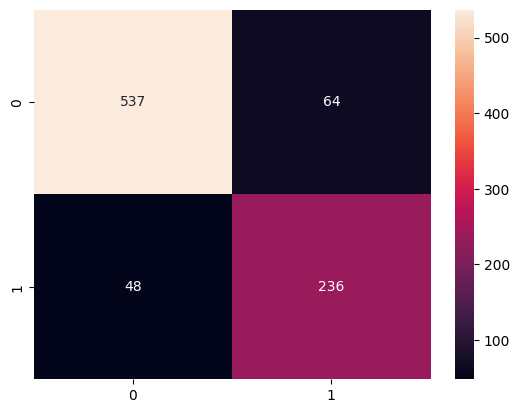

In [135]:

logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_lr = logreg_pipeline.predict(X_test)
y_prob_lr = logreg_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.show()


## 11. Random Forest

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       601
           1       0.88      0.73      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885

ROC-AUC: 0.9310245834407443


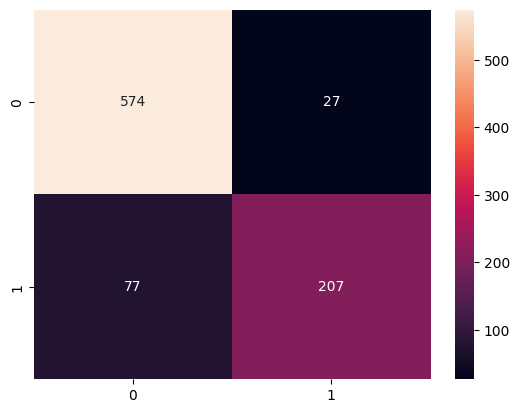

In [136]:

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.show()


## 12. Perbandingan Model

In [137]:

results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Accuracy':[accuracy_score(y_test,y_pred_lr), accuracy_score(y_test,y_pred_rf)],
    'Precision':[precision_score(y_test,y_pred_lr), precision_score(y_test,y_pred_rf)],
    'Recall':[recall_score(y_test,y_pred_lr), recall_score(y_test,y_pred_rf)],
    'F1':[f1_score(y_test,y_pred_lr), f1_score(y_test,y_pred_rf)],
    'ROC-AUC':[roc_auc_score(y_test,y_prob_lr), roc_auc_score(y_test,y_prob_rf)]
})
results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.873446,0.786667,0.830986,0.808219,0.927175
1,Random Forest,0.882486,0.884615,0.728873,0.799228,0.931025


## 13. Hyperparameter Tuning Random Forest

In [138]:

rf_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'model__n_estimators':[100,200],
    'model__max_depth':[None,5,10],
    'model__min_samples_split':[2,5],
    'model__min_samples_leaf':[1,2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_rf = GridSearchCV(rf_tuning_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(grid_rf.best_params_)
print(grid_rf.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
0.791310371628186


## 14. Simpan Model

In [139]:

import joblib
joblib.dump(best_rf, 'model_dropout_mahasiswa.pkl')
print('Model tersimpan')


Model tersimpan


In [140]:
import os

output_dir = "/kaggle/working/data/processed"
os.makedirs(output_dir, exist_ok=True)

In [141]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/dataset/data.csv', sep=';')

In [142]:
import os

output_dir = "/kaggle/working/data/processed"
os.makedirs(output_dir, exist_ok=True)

In [143]:
from sklearn.model_selection import train_test_split

df['dropout_risk'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

X = df.drop(columns=['Target', 'dropout_risk'])
y = df['dropout_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [144]:
X_train.to_csv(f"{output_dir}/X_train.csv", index=False)
X_test.to_csv(f"{output_dir}/X_test.csv", index=False)
y_train.to_csv(f"{output_dir}/y_train.csv", index=False)
y_test.to_csv(f"{output_dir}/y_test.csv", index=False)

In [145]:
import os
from sklearn.model_selection import train_test_split

# =========================
# 1. Pastikan target biner sudah ada
# =========================
df['dropout_risk'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

# =========================
# 2. Buat folder output
# =========================
os.makedirs('/kaggle/working/data/processed', exist_ok=True)

# =========================
# 3. Split train dan test
# stratify dipakai agar proporsi kelas target tetap seimbang
# =========================
train_df, test_df = train_test_split(
    df,
    test_size=0.2,          # 80% train, 20% test
    random_state=42,        # biar hasil split selalu sama
    stratify=df['dropout_risk']
)

# =========================
# 4. Simpan ke CSV
# =========================
train_df.to_csv('/kaggle/working/data/processed/train.csv', index=False)
test_df.to_csv('/kaggle/working/data/processed/test.csv', index=False)

# optional: simpan juga full processed data
df.to_csv('/kaggle/working/data/processed/processed_data.csv', index=False)

# =========================
# 5. Cek hasil
# =========================
print("Berhasil membuat file:")
print("/kaggle/working/data/processed/train.csv")
print("/kaggle/working/data/processed/test.csv")
print("/kaggle/working/data/processed/processed_data.csv")

print("\nShape train:", train_df.shape)
print("Shape test :", test_df.shape)

print("\nDistribusi target di TRAIN:")
print(train_df['dropout_risk'].value_counts(normalize=True))

print("\nDistribusi target di TEST:")
print(test_df['dropout_risk'].value_counts(normalize=True))

Berhasil membuat file:
/kaggle/working/data/processed/train.csv
/kaggle/working/data/processed/test.csv
/kaggle/working/data/processed/processed_data.csv

Shape train: (3539, 38)
Shape test : (885, 38)

Distribusi target di TRAIN:
dropout_risk
0    0.678723
1    0.321277
Name: proportion, dtype: float64

Distribusi target di TEST:
dropout_risk
0    0.679096
1    0.320904
Name: proportion, dtype: float64


In [146]:
train_df.to_csv('/kaggle/working/data/processed/train.csv', index=False)
test_df.to_csv('/kaggle/working/data/processed/test.csv', index=False)

In [147]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [148]:
train_df = pd.read_csv('/kaggle/working/data/processed/train.csv')
test_df  = pd.read_csv('/kaggle/working/data/processed/test.csv')

print(train_df.shape, test_df.shape)
display(train_df.head())

(3539, 38) (885, 38)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,dropout_risk
0,1,1,1,9147,1,1,130.0,1,38,37,...,5,5,1,12.000000,0,7.6,2.6,0.32,Dropout,1
1,1,1,1,9853,1,1,129.0,1,38,37,...,6,10,4,11.500000,0,7.6,2.6,0.32,Dropout,1
2,2,39,1,9991,0,1,140.0,1,37,37,...,5,9,2,11.000000,0,12.7,3.7,-1.70,Dropout,1
3,1,17,2,9670,1,1,129.0,1,19,19,...,6,10,5,13.125000,0,10.8,1.4,1.74,Dropout,1
4,1,1,3,9085,1,1,138.0,1,1,1,...,6,12,6,13.833333,0,8.9,1.4,3.51,Graduate,0


In [149]:
X_train = train_df.drop(columns=['Target', 'dropout_risk'])
y_train = train_df['dropout_risk']

X_test = test_df.drop(columns=['Target', 'dropout_risk'])
y_test = test_df['dropout_risk']

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (3539, 36)
X_test : (885, 36)


In [150]:
numeric_features = X_train.columns.tolist()
categorical_features = []

In [151]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)

In [152]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    ))
])

In [153]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Marital status',
                                                   'Application mode',
                                                   'Application order',
                                                   'Course',
                                                   'Daytime/evening '
                                                   'attendance\t',
                                                   'Previous qualification',
                                                   'Previous qualification '
                                                   '(grade)',
                                                   'Nacionality',
                                                   "Mother's qualification...
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curricular units 1st sem '
                                                   '(without evaluations)',
                                                   'Curricular units 2nd sem '
                                                   '(credited)',
                                                   'Curricular units 2nd sem '
                                                   '(enrolled)',
                                                   'Curricular units 2nd sem '
                                                   '(evaluations)', ...])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

In [154]:
y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.880225988700565
F1-score : 0.8058608058608059

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       601
           1       0.84      0.77      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885


Confusion Matrix:

[[559  42]
 [ 64 220]]


In [155]:
os.makedirs('/kaggle/working/models', exist_ok=True)

joblib.dump(best_model, '/kaggle/working/models/full_pipeline.pkl')
joblib.dump(best_model.named_steps['preprocessor'], '/kaggle/working/models/preprocessor.pkl')
joblib.dump(best_model.named_steps['model'], '/kaggle/working/models/random_forest_model.pkl')

print("File berhasil disimpan:")
print(os.listdir('/kaggle/working/models'))

File berhasil disimpan:
['random_forest_model.pkl', 'full_pipeline.pkl', 'preprocessor.pkl']
